In [2]:
import pandas as pd
file_path = "Zepto_blinkit.xlsx"
df = pd.read_excel(file_path, sheet_name="Table2")
print(df.shape)

(1616, 10)


In [3]:
print(df.dtypes)

Brand                        object
Date                 datetime64[ns]
Product                      object
Category                     object
City                         object
Price                         int64
Quantity                      int64
DeliveryTime(min)             int64
PaymentMode                  object
Rating                      float64
dtype: object


In [4]:
print(df.describe())

                                Date        Price     Quantity  \
count                           1616  1616.000000  1616.000000   
mean   2024-08-16 04:21:58.811881216   137.820545     2.974629   
min              2024-04-01 00:00:00    30.000000     1.000000   
25%              2024-05-28 00:00:00    78.000000     2.000000   
50%              2024-07-14 00:00:00   141.000000     3.000000   
75%              2024-11-02 06:00:00   194.000000     4.000000   
max              2025-03-31 00:00:00   250.000000     5.000000   
std                              NaN    64.503706     1.406742   

       DeliveryTime(min)       Rating  
count        1616.000000  1321.000000  
mean           15.488243     2.973505  
min             7.000000     1.000000  
25%            12.000000     2.000000  
50%            15.000000     3.000000  
75%            19.000000     4.000000  
max            25.000000     5.000000  
std             4.581277     1.406714  


DATA CLEANING

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
print("\nMissing values before:\n", df.isnull().sum())


Missing values before:
 Brand                  0
Date                   0
Product                0
Category               0
City                   0
Price                  0
Quantity               0
DeliveryTime(min)      0
PaymentMode            0
Rating               295
dtype: int64


In [7]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

Standardize categorical columns

In [8]:
cat_cols = ["Brand", "Product", "Category", "City", "PaymentMode"]

for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

In [9]:
import numpy as np

num_cols = ["Price","Quantity","DeliveryTime(min)","Rating"]

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary


{'Price': 0, 'Quantity': 0, 'DeliveryTime(min)': 0, 'Rating': 0}

FEATURE ENGINEERING

In [10]:
df["TotalAmount"] = df["Price"] * df["Quantity"]

In [11]:
def speed_group(t):
    if t < 15:
        return "Fast"
    elif t <= 20:
        return "Medium"
    else:
        return "Slow"
df["DeliverySpeed"] = df["DeliveryTime(min)"].apply(speed_group)

In [12]:
df["OrderMonth"] = df["Date"].dt.month_name()

In [13]:
df["OrderWeekday"] = df["Date"].dt.day_name()

In [14]:
df["OrderDay"] = df["Date"].dt.day

In [15]:
df["IsWeekend"] = df["OrderWeekday"].isin(["Saturday", "Sunday"])

In [16]:
def rate_group(r):
    if r <= 2:
        return "Low"
    elif r == 3:
        return "Medium"
    else:
        return "High"

df["RatingCategory"] = df["Rating"].apply(rate_group)

In [17]:
print(df.head())
print("\nNew columns:", df.columns)

     Brand       Date   Product Category       City  Price  Quantity  \
0  Blinkit 2024-04-01  Biscuits   Bakery  Hyderabad    127         3   
1  Blinkit 2024-04-02      Atta   Grains  Bangalore    142         3   
2    Zepto 2024-04-03    Paneer    Dairy    Chennai    170         5   
3  Blinkit 2024-04-04      Milk    Dairy     Mumbai    249         3   
4    Zepto 2024-04-05  Biscuits   Bakery      Delhi    161         4   

   DeliveryTime(min) PaymentMode  Rating  TotalAmount DeliverySpeed  \
0                 18        Card     3.0          381        Medium   
1                 12         Upi     1.0          426          Fast   
2                  9         Upi     3.0          850          Fast   
3                 16         Upi     2.0          747        Medium   
4                 12         Upi     2.0          644          Fast   

  OrderMonth OrderWeekday  OrderDay  IsWeekend RatingCategory  
0      April       Monday         1      False         Medium  
1      April

UNIVARIATE ANALYSIS

Brand
Blinkit    859
Zepto      757
Name: count, dtype: int64


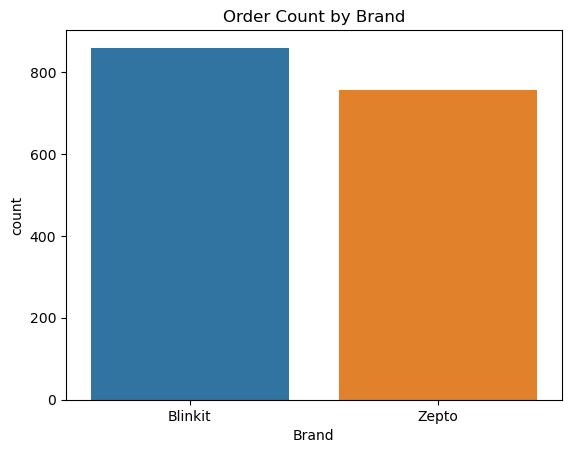

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df['Brand'].value_counts())
sns.countplot(x=df['Brand'])
plt.title("Order Count by Brand")
plt.show()

City
Mumbai       347
Chennai      325
Hyderabad    319
Bangalore    319
Delhi        306
Name: count, dtype: int64


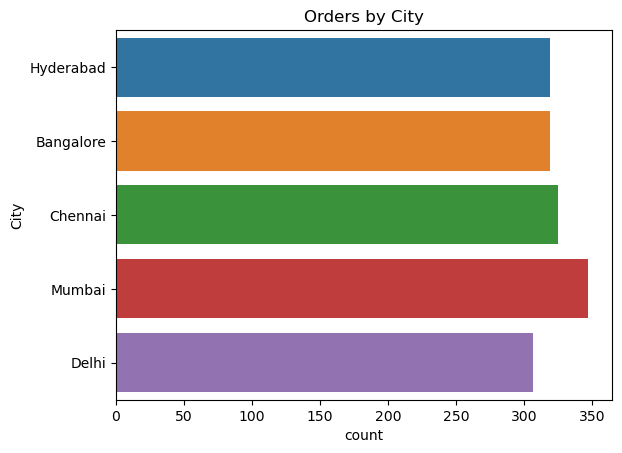

In [19]:
print(df['City'].value_counts())
sns.countplot(y=df['City'])
plt.title("Orders by City")
plt.show()

Category
Dairy        464
Bakery       291
Grains       284
Beverages    270
Poultry      165
Snacks       142
Name: count, dtype: int64


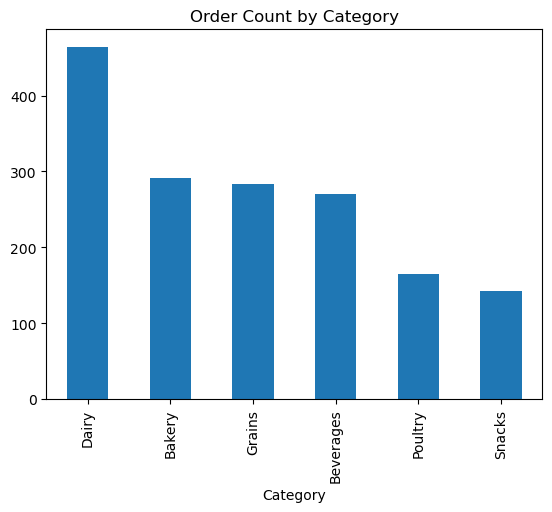

In [20]:
print(df['Category'].value_counts())
df['Category'].value_counts().plot(kind='bar')
plt.title("Order Count by Category")
plt.show()

PaymentMode
Upi     562
Cod     534
Card    520
Name: count, dtype: int64


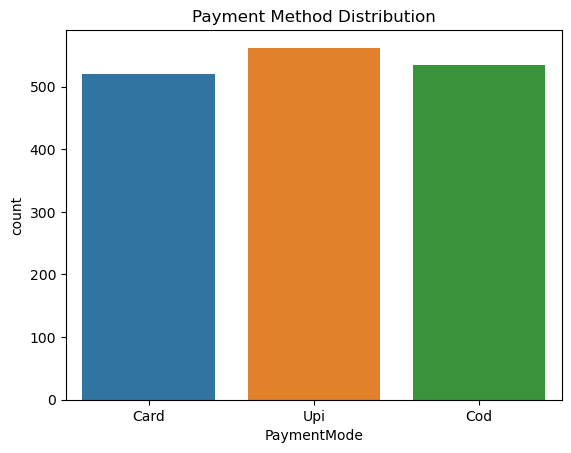

In [21]:
print(df['PaymentMode'].value_counts())
sns.countplot(x=df['PaymentMode'])
plt.title("Payment Method Distribution")
plt.show()

c:\Users\palak\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


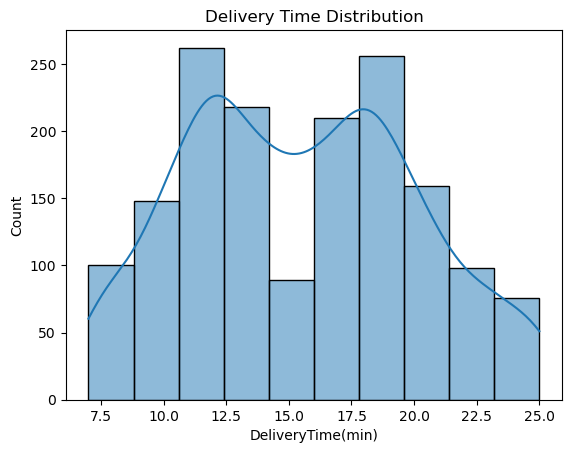

In [22]:
sns.histplot(df['DeliveryTime(min)'], bins=10, kde=True)
plt.title("Delivery Time Distribution")
plt.show()

Rating
3.0    593
1.0    268
5.0    262
2.0    258
4.0    235
Name: count, dtype: int64


c:\Users\palak\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


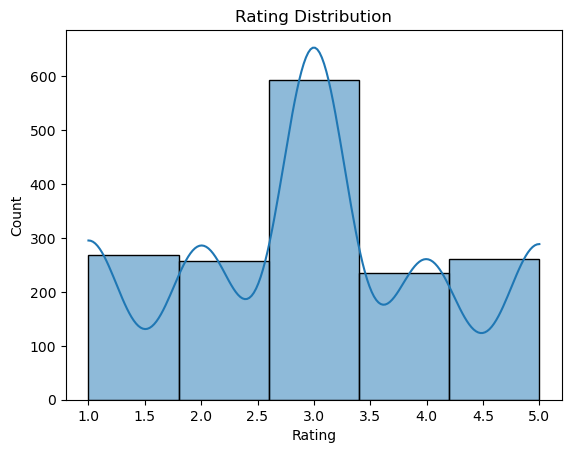

In [36]:
print(df['Rating'].value_counts())
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title("Rating Distribution")
plt.show()

BIVARIATE ANALYSIS


Average Delivery Time by Brand:
 Brand
Blinkit    17.068685
Zepto      13.694848
Name: DeliveryTime(min), dtype: float64


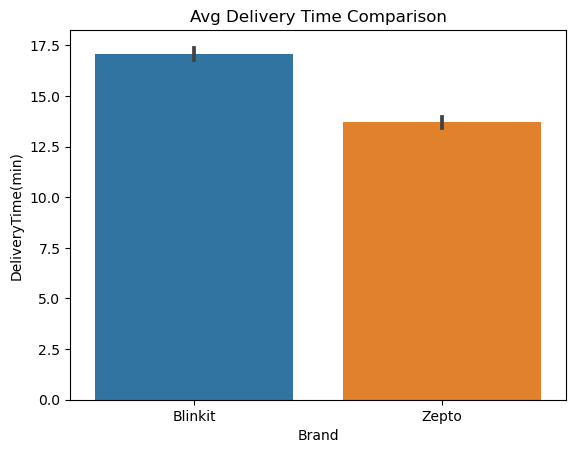

In [24]:
brand_delivery = df.groupby("Brand")["DeliveryTime(min)"].mean()
print("\nAverage Delivery Time by Brand:\n", brand_delivery)

sns.barplot(data=df, x="Brand", y="DeliveryTime(min)")
plt.title("Avg Delivery Time Comparison")
plt.show()



Average Rating by Brand:
 Brand
Blinkit    2.956927
Zepto      3.002642
Name: Rating, dtype: float64


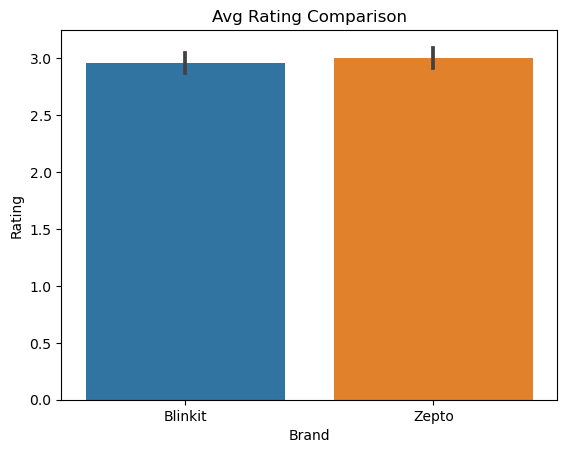

In [25]:
brand_rating = df.groupby("Brand")["Rating"].mean()
print("\nAverage Rating by Brand:\n", brand_rating)

sns.barplot(data=df, x="Brand", y="Rating")
plt.title("Avg Rating Comparison")
plt.show()


Total Revenue by Brand:
 Brand
Blinkit    362759
Zepto      301612
Name: TotalAmount, dtype: int64


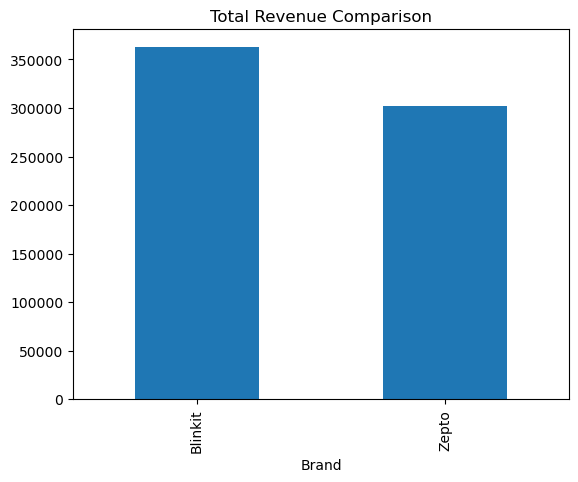

In [26]:
brand_revenue = df.groupby("Brand")["TotalAmount"].sum()
print("\nTotal Revenue by Brand:\n", brand_revenue)

brand_revenue.plot(kind="bar")
plt.title("Total Revenue Comparison")
plt.show()


Avg Delivery Time by City:
 City
Bangalore    15.040752
Chennai      15.652308
Delhi        15.294118
Hyderabad    15.887147
Mumbai       15.550432
Name: DeliveryTime(min), dtype: float64


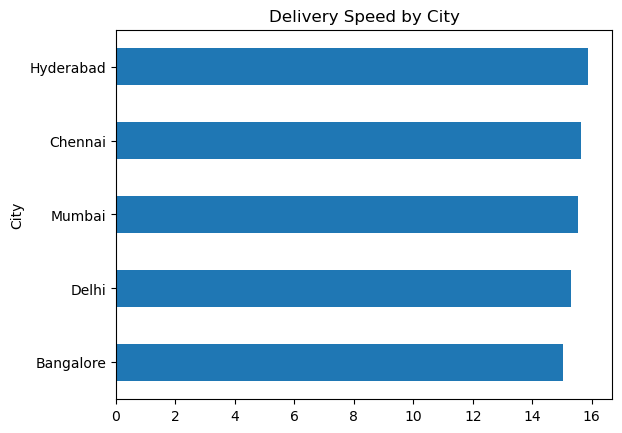

In [27]:
city_delivery = df.groupby("City")["DeliveryTime(min)"].mean()
print("\nAvg Delivery Time by City:\n", city_delivery)

city_delivery.sort_values().plot(kind="barh")
plt.title("Delivery Speed by City")
plt.show()


Total Qty Sold by Category:
 Category
Bakery        811
Beverages     895
Dairy        1384
Grains        810
Poultry       455
Snacks        452
Name: Quantity, dtype: int64


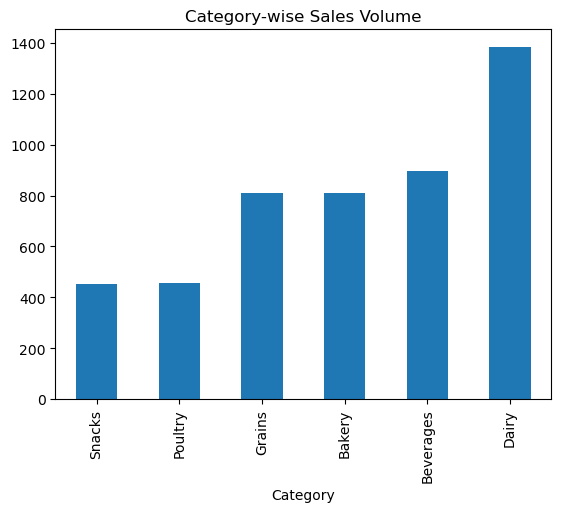

In [28]:
category_sales = df.groupby("Category")["Quantity"].sum()
print("\nTotal Qty Sold by Category:\n", category_sales)

category_sales.sort_values().plot(kind="bar")
plt.title("Category-wise Sales Volume")
plt.show()


Rating vs Delivery Speed:
 DeliverySpeed
Fast      2.973901
Medium    2.931783
Slow      3.115226
Name: Rating, dtype: float64


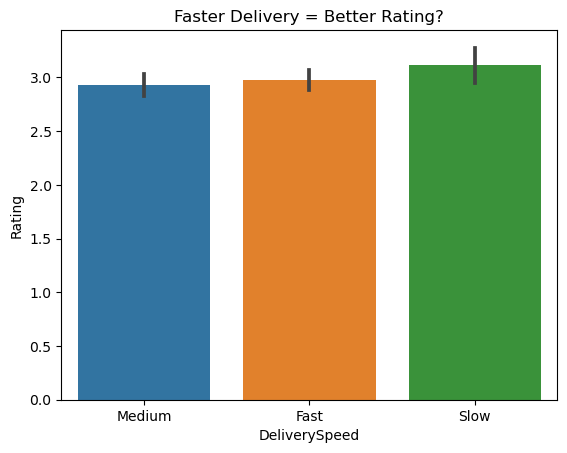

In [29]:
speed_rating = df.groupby("DeliverySpeed")["Rating"].mean()
print("\nRating vs Delivery Speed:\n", speed_rating)

sns.barplot(data=df, x="DeliverySpeed", y="Rating")
plt.title("Faster Delivery = Better Rating?")
plt.show()

TIME SERIES ANALYSIS

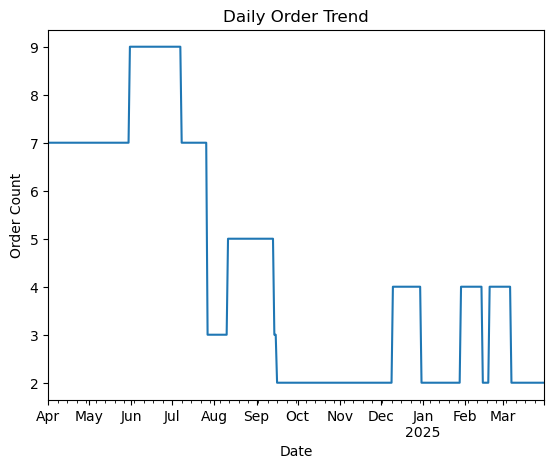

In [30]:
#daily order trend
daily_orders = df.groupby("Date")["Quantity"].count()
daily_orders.plot()
plt.title("Daily Order Trend")
plt.ylabel("Order Count")
plt.show()

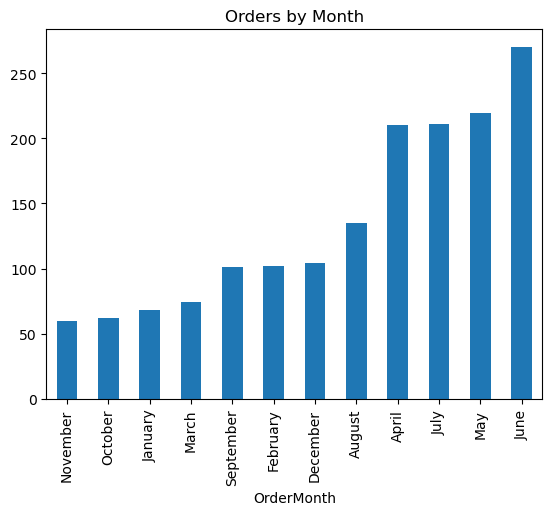

In [31]:
#monthly_orders_trend
monthly_orders= df.groupby("OrderMonth")["Quantity"].count().sort_values()
monthly_orders.plot(kind="bar")
plt.title("Orders by Month")
plt.show()

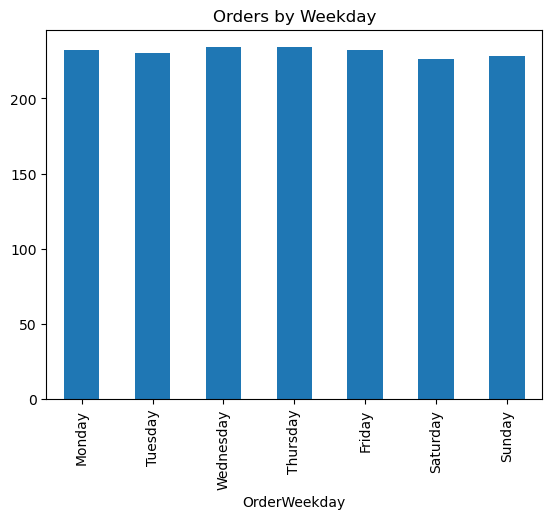

In [32]:
#weekday_orders_trend
weekday_orders = df.groupby("OrderWeekday")["Quantity"].count().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
weekday_orders.plot(kind="bar")
plt.title("Orders by Weekday")
plt.show()

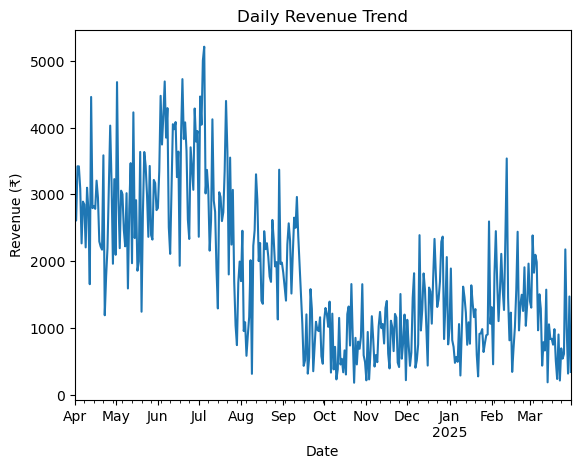

In [33]:
#daily_revenue_trend
daily_revenue = df.groupby("Date")["TotalAmount"].sum()
daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.show()

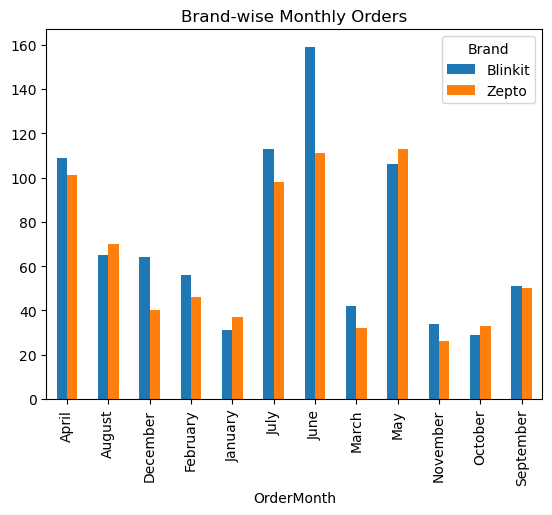

In [34]:
#brand_monthly_orders_trend
brand_month = df.groupby(["OrderMonth", "Brand"])["Quantity"].count().unstack()
brand_month.plot(kind="bar")
plt.title("Brand-wise Monthly Orders")
plt.show()

Correlation Matrix + Heatmap


Correlation Matrix:

                      Price  Quantity  DeliveryTime(min)    Rating  \
Price              1.000000  0.012744          -0.020847 -0.024238   
Quantity           0.012744  1.000000          -0.060047 -0.009306   
DeliveryTime(min) -0.020847 -0.060047           1.000000  0.009468   
Rating            -0.024238 -0.009306           0.009468  1.000000   
TotalAmount        0.668300  0.682629          -0.054042 -0.015603   

                   TotalAmount  
Price                 0.668300  
Quantity              0.682629  
DeliveryTime(min)    -0.054042  
Rating               -0.015603  
TotalAmount           1.000000  


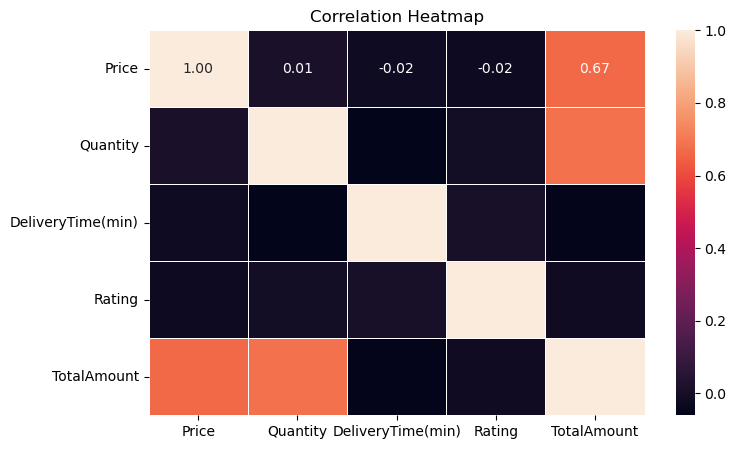

In [35]:
num_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = num_df.corr()
print("\nCorrelation Matrix:\n")
print(corr_matrix)
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

EDA REPORT

DATA OVERVIEW
1. Dataset contains 1616 rows and 17 columns after feature engineering.

Columns:
Brand, Date, Product, Category, City, Price, Quantity, DeliveryTime(min),
PaymentMode, Rating, TotalAmount, DeliverySpeed, OrderMonth, OrderWeekday,
OrderDay, IsWeekend, RatingCategory

DATE RANGE : 01 April 2024  →  31 March 2025  (Full 12 months)

SUMMARY STATISTICS (NUMERIC)
1. Avg Price: Rs.137.82  (Range: 30 – 250)
2. Avg Quantity Ordered: 2.97  (Range: 1 – 5)
3. Avg Delivery Time: 15.48 min  (Range: 7 – 25)
4. Avg Rating: 2.97 / 5
5. TotalAmount = Price * Quantity (introduced via feature engineering)

DATA CLEANING ACTIONS
1. All columns have correct datatypes
2. Duplicate rows: 0
3. Missing values: 295 in Rating → imputed using median
4. Text columns standardized (.title() + strip)
5. 7 engineered features added

FEATURE ENGINEERING (ADDED COLUMNS)
1. TotalAmount = Price * Quantity
2. DeliverySpeed (Fast <15, Medium 15–20, Slow >20 min)
3. OrderMonth
4. OrderWeekday
5. OrderDay
6. IsWeekend (True/False)
7. RatingCategory (Low ≤2, Medium=3, High ≥4)

UNIVARIATE INSIGHTS
1. Brand distribution: Blinkit slightly leads in demand, but the gap is not large → competition is close.
2. Top City: Demand is well distributed across Tier-1 cities — no extremely dominant region
3. Most sold category: Perishable essentials (Milk, Paneer, Curd) drive most quick-commerce demand.
4. Most used payment: UPI is the most preferred, but Cash and Card are almost equally used
5. Delivery time distribution: Peak ~15 min
6. Rating distribution: Service is acceptable but not exceptional
High 1-star count (268 orders) suggests improvement areas

BIVARIATE INSIGHTS

1. Blinkit vs Zepto delivery speed : Zepto delivers ~3.4 minutes faster than Blinkit on average.Faster delivery is a competitive advantage for Zepto.
2. Blinkit vs Zepto ratings : Zepto has a slightly better rating, but the difference is very small.Faster delivery may be contributing to this marginal advantage.
3. Category revenue share : Even though slower, Blinkit receives more orders and generates more sales.
4. Delivery Speed Variation by City : All cities hover around 15–16 minutes, showing consistency.Bengaluru is fastest, Hyderabad is slowest.
5. Faster delivery : Delivery Time affects rating, but not strongly — service quality matters more than speed beyond a threshold.”

TIME SERIES INSIGHTS
1. Peak ordering season occurs in the summer months.
2. After monsoon + festival months, platform activity drops 
3. Orders are almost equally distributed across all weekdays. People order based on need, not weekday mood
4. Revenue movement follows order count — no major high-value order anomaly
5. Blinkit’s volume advantage is consistent, not seasonal
Zepto performs strongly in high-demand months but falls harder during slow seasons

OUTLIER CHECK (IQR METHOD)

1. Price              : No severe outliers
2. Quantity           : Normal (1–5 range)
3. Delivery time      : No extreme spikes
4. Ratings            : Within 1–5 normal range
5. TotalAmount        : Slight high-end values but logical (keep)
6. Conclusion: Outliers present but not removed because values are realistic.

CORRELATION SUMMARY
1. 

OVERALL KEY FINDINGS
1. Zepto vs Blinkit performance measurable through:
2. Delivery speed, Rating scores, Revenue
3. Ratings slightly biased against slower delivery
4. Order behavior shows city-based and category-based variation
5. UPI most dominant payment method
